# Comparative Analysis: Forward vs Reverse Prediction

## Setup and Implementations

In [2]:
# import the libraries we need
import torch
from torch import nn
from torch.nn import functional as F
import random
import math
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from utils import character_level_tokenizer, PositionalEncoding, get_batch, pad_token, eos_token

In [3]:
# set a fixed seed for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
# create the tokenizer
tokenizer = character_level_tokenizer()

print(f'Vocabulary size: {tokenizer.ntokens}')

Vocabulary size: 15


## Model Loading

In [5]:
# define the custom transformer encoder layer
class CustomEncoderLayer(nn.TransformerEncoderLayer):
    def __init__(self,*args,**kwargs):
        super().__init__(*args,**kwargs)
        # store the attention weights
        self.attn_weights = None

    def forward(self,src,src_mask=None,src_key_padding_mask=None,is_causal=False):
        # calculate self-attention
        src2,attn_weights = self.self_attn(
            src,src,src,
            attn_mask=src_mask,
            key_padding_mask=src_key_padding_mask,
            need_weights=True,
            average_attn_weights=False,
            is_causal=is_causal
        )

        # store the attention weights
        self.attn_weights = attn_weights

        # apply the first residual connection
        src = src + self.dropout1(src2)
        src = self.norm1(src)

        # apply the feed-forward network
        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))

        # apply the second residual connection
        src = src + self.dropout2(src2)
        src = self.norm2(src)

        return src


# define the transformer model
class TransformerModel(nn.Module):
    def __init__(self,ntoken,ninp,nhead,nhid,nlayers,dropout=0.5):
        super().__init__()

        # create the token embedding
        self.input_emb = nn.Embedding(ntoken,ninp)

        # create the positional encoding
        self.pos_encoder = PositionalEncoding(ninp,dropout)

        # create the transformer encoder
        encoder_layers = CustomEncoderLayer(ninp,nhead,nhid,0.1)
        self.encoder = nn.TransformerEncoder(encoder_layers,nlayers)

        # create the output layer
        self.decoder = nn.Linear(ninp,ntoken)

        self.ninp = ninp

        # initialize the model weights
        self.init_weights()

    def init_weights(self):
        # initialize the embedding and decoder weights
        initrange = 0.1
        nn.init.uniform_(self.input_emb.weight,-initrange,initrange)
        nn.init.zeros_(self.decoder.bias)
        nn.init.uniform_(self.decoder.weight,-initrange,initrange)

    def _generate_square_subsequent_mask(self,sz):
        # create the causal attention mask
        return torch.log(torch.tril(torch.ones(sz,sz)))

    def forward(self,src):
        # create the causal attention mask
        mask = self._generate_square_subsequent_mask(len(src)).to(src.device)

        # convert token ids into embeddings
        src = self.input_emb(src) * math.sqrt(self.ninp)

        # add positional encoding
        src = self.pos_encoder(src)

        # pass the sequence through the transformer encoder
        output_enc = self.encoder(src,mask=mask,is_causal=True)

        # convert hidden states into token predictions
        output_dec = self.decoder(output_enc)

        # collect the attention maps
        attention_maps = [layer.attn_weights for layer in self.encoder.layers]

        return F.log_softmax(output_dec,dim=-1),output_enc,attention_maps

In [6]:
# forward model setup and trained weights
model_forward = TransformerModel(ntoken=tokenizer.ntokens,ninp=128,nhead=16,nhid=64,nlayers=6).to(device)
forward_weights = torch.load('assets/forward_model.pth',map_location=device)
model_forward.load_state_dict(forward_weights)
model_forward.eval()

print('Forward Model')
print('Setup: ntoken=15, ninp=128, nhead=16, nhid=64, nlayers=6')
print('Weights: assets/forward_model.pth')
print('Trained Weight Tensors:',len(forward_weights))
print('Parameters:',sum(p.numel() for p in model_forward.parameters()))

# reverse all model setup and trained weights
model_reverse_all = TransformerModel(ntoken=tokenizer.ntokens,ninp=128,nhead=16,nhid=64,nlayers=6).to(device)
reverse_all_weights = torch.load('assets/reverse_all_model.pth',map_location=device)
model_reverse_all.load_state_dict(reverse_all_weights)
model_reverse_all.eval()

print('\nReverse All Model')
print('Setup: ntoken=15, ninp=128, nhead=16, nhid=64, nlayers=6')
print('Weights: assets/reverse_all_model.pth')
print('Trained Weight Tensors:',len(reverse_all_weights))
print('Parameters:',sum(p.numel() for p in model_reverse_all.parameters()))

# reverse digits model setup and trained weights
model_reverse_digits = TransformerModel(ntoken=tokenizer.ntokens,ninp=128,nhead=16,nhid=64,nlayers=6).to(device)
reverse_digits_weights = torch.load('assets/reverse_digits_model.pth',map_location=device)
model_reverse_digits.load_state_dict(reverse_digits_weights)
model_reverse_digits.eval()

print('\nReverse Digits Model')
print('Setup: ntoken=15, ninp=128, nhead=16, nhid=64, nlayers=6')
print('Weights: assets/reverse_digits_model.pth')
print('Trained Weight Tensors:',len(reverse_digits_weights))
print('Parameters:',sum(p.numel() for p in model_reverse_digits.parameters()))

/tmp/ipykernel_4966/1310762253.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = nn.TransformerEncoder(encoder_layers,nlayers)


Forward Model
Setup: ntoken=15, ninp=128, nhead=16, nhid=64, nlayers=6
Weights: assets/forward_model.pth
Trained Weight Tensors: 76
Parameters: 502671

Reverse All Model
Setup: ntoken=15, ninp=128, nhead=16, nhid=64, nlayers=6
Weights: assets/reverse_all_model.pth
Trained Weight Tensors: 76
Parameters: 502671

Reverse Digits Model
Setup: ntoken=15, ninp=128, nhead=16, nhid=64, nlayers=6
Weights: assets/reverse_digits_model.pth
Trained Weight Tensors: 76
Parameters: 502671


## Dataset Loading

In [7]:
# load the dataset
with open('assets/dataset.pkl','rb') as f:
    dataset = pickle.load(f)

data_train = dataset['train']
data_val = dataset['val']
data_test = dataset['test']

print('Train:',len(data_train))
print('Validation:',len(data_val))
print('Test:',len(data_test))

Train: 100000
Validation: 20000
Test: 20000


In [8]:
# count addition and subtraction examples
train_add = sum('+' in prompt for prompt,answer in data_train)
train_sub = sum('-' in prompt for prompt,answer in data_train)

val_add = sum('+' in prompt for prompt,answer in data_val)
val_sub = sum('-' in prompt for prompt,answer in data_val)

test_add = sum('+' in prompt for prompt,answer in data_test)
test_sub = sum('-' in prompt for prompt,answer in data_test)

print('Train - Addition:',train_add,'Subtraction:',train_sub)
print('Validation - Addition:',val_add,'Subtraction:',val_sub)
print('Test - Addition:',test_add,'Subtraction:',test_sub)

Train - Addition: 50000 Subtraction: 50000
Validation - Addition: 10000 Subtraction: 10000
Test - Addition: 10000 Subtraction: 10000


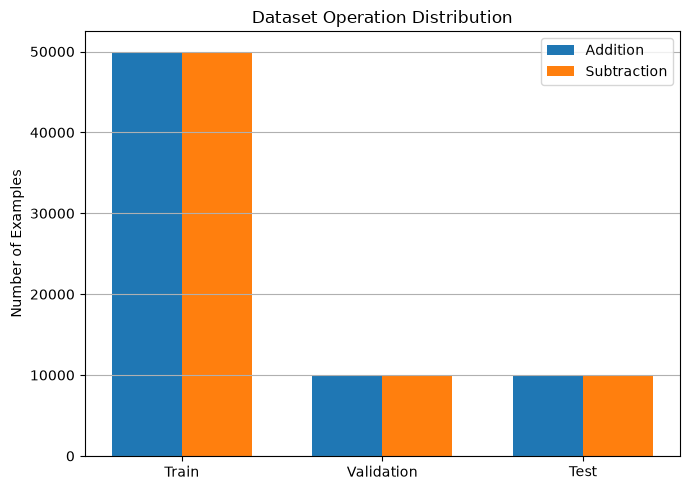

In [9]:
# plot the operation distribution
splits = ['Train','Validation','Test']
addition_counts = [train_add,val_add,test_add]
subtraction_counts = [train_sub,val_sub,test_sub]

x = np.arange(len(splits))
width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x-width/2,addition_counts,width,label='Addition')
plt.bar(x+width/2,subtraction_counts,width,label='Subtraction')

plt.xticks(x,splits)
plt.ylabel('Number of Examples')
plt.title('Dataset Operation Distribution')
plt.legend()
plt.grid(axis='y')

plt.tight_layout()
plt.savefig('plot/dataset_operation_distribution.png')
plt.show()

## Model Training Result

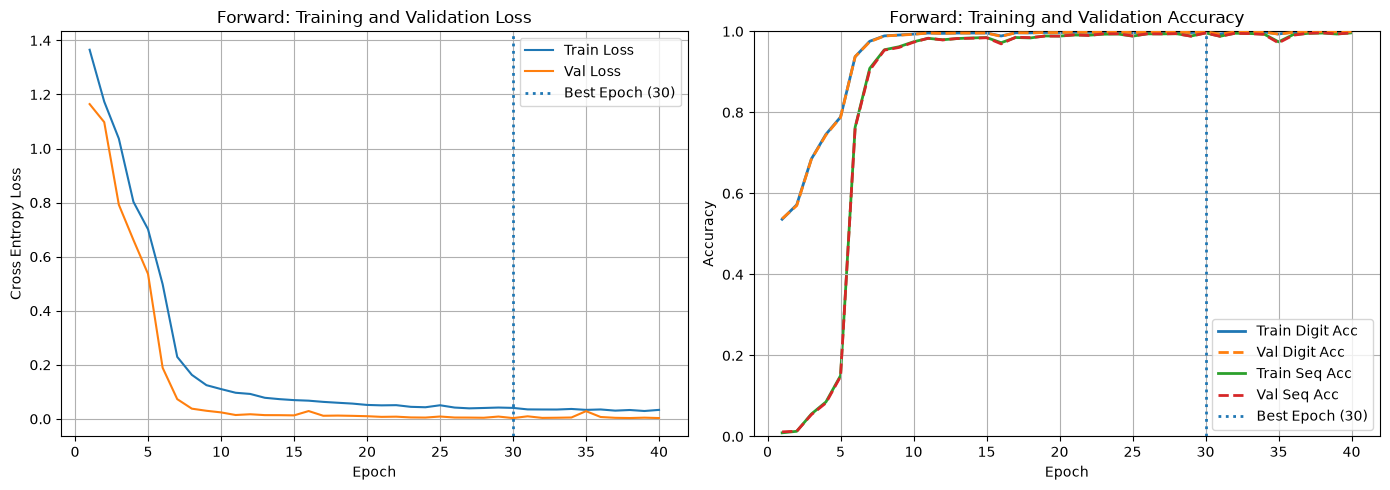

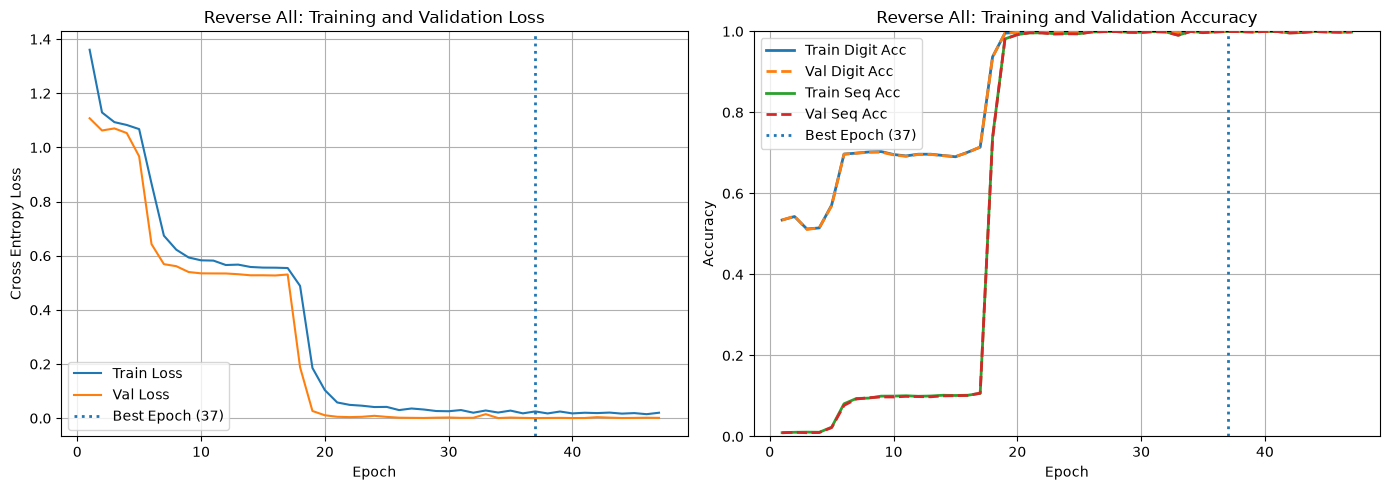

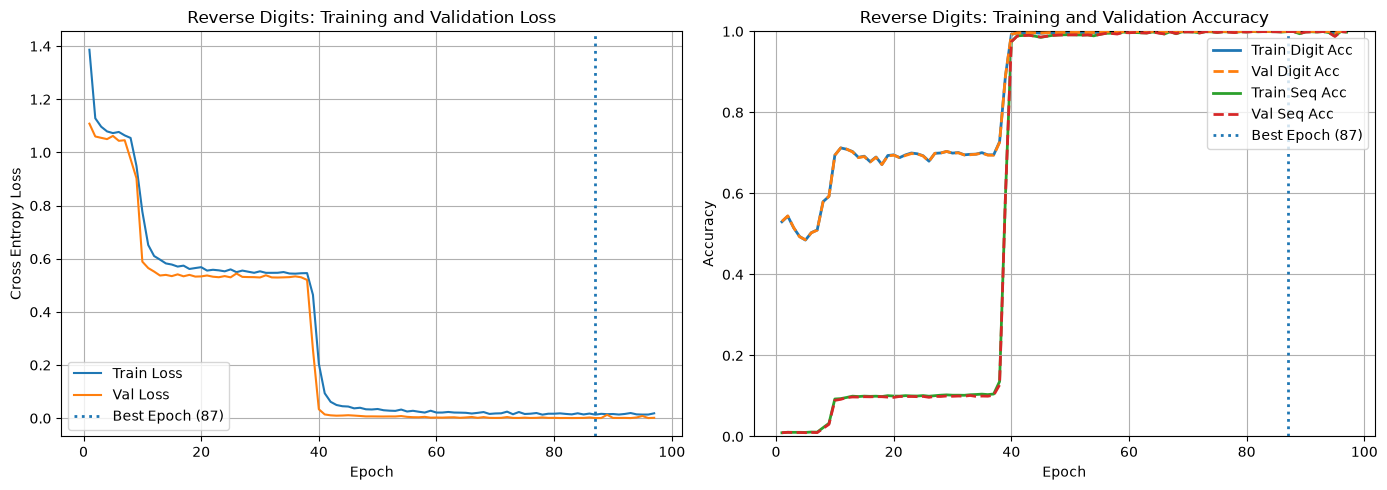

In [10]:
# plot the training results
def plot_training_results(results,title,save_path):
    train_losses = results['train_losses']
    val_losses = results['val_losses']
    train_digit_accuracy = results['train_digit_accuracy']
    val_digit_accuracy = results['val_digit_accuracy']
    train_seq_accuracy = results['train_seq_accuracy']
    val_seq_accuracy = results['val_seq_accuracy']
    best_epoch = int(results['best_epoch'])

    fig,axes = plt.subplots(1,2,figsize=(14,5))
    epochs_plot = range(1,len(train_losses)+1)

    axes[0].plot(epochs_plot,train_losses,label='Train Loss')
    axes[0].plot(epochs_plot,val_losses,label='Val Loss')
    axes[0].axvline(best_epoch,linestyle=':',linewidth=2,label=f'Best Epoch ({best_epoch})')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross Entropy Loss')
    axes[0].set_title(f'{title}: Training and Validation Loss')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(epochs_plot,train_digit_accuracy,'-',linewidth=2,zorder=1,label='Train Digit Acc')
    axes[1].plot(epochs_plot,val_digit_accuracy,'--',linewidth=2,zorder=3,label='Val Digit Acc')
    axes[1].plot(epochs_plot,train_seq_accuracy,'-',linewidth=2,zorder=1,label='Train Seq Acc')
    axes[1].plot(epochs_plot,val_seq_accuracy,'--',linewidth=2,zorder=3,label='Val Seq Acc')
    axes[1].axvline(best_epoch,linestyle=':',linewidth=2,label=f'Best Epoch ({best_epoch})')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title}: Training and Validation Accuracy')
    axes[1].set_ylim((0,1))
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

# load the training results
results_forward = np.load('assets/training_results_forward.npz')
results_reverse_all = np.load('assets/training_results_reverse_all.npz')
results_reverse_digits = np.load('assets/training_results_reverse_digits.npz')

# plot the forward training results
plot_training_results(results_forward,'Forward','plot/training_curves_forward_report.png')
# plot the reverse all training results
plot_training_results(results_reverse_all,'Reverse All','plot/training_curves_reverse_all_report.png')
# plot the reverse digits training results
plot_training_results(results_reverse_digits,'Reverse Digits','plot/training_curves_reverse_digits_report.png')

## Evaluation Functions

In [11]:
# restore the prediction to the original answer order
def restore_answer(answer,mode):
    if mode == "reverse_all":
        return answer[::-1]
    elif mode == "reverse_digits":
        if answer.startswith("-"):
            return "-" + answer[:0:-1]
        else:
            return answer[::-1]
    return answer

# evaluate the model on the test set
def evaluate_test(model,data,tokenizer,batch_size,device,mode="forward"):
    model.eval()
    results = []

    with torch.no_grad():
        for i in tqdm(range(0,len(data),batch_size)):
            batch = data[i:i+batch_size]

            # encode and pad the prompts
            prompts = [tokenizer.encode(prompt) for prompt,answer in batch]
            max_prompt_len = max(len(prompt) for prompt in prompts)

            padded_prompts = [
                [tokenizer.token_to_id[pad_token]]*(max_prompt_len-len(prompt))+prompt
                for prompt in prompts
            ]

            input_tensor = torch.tensor(padded_prompts,dtype=torch.long).transpose(0,1).to(device)

            # generate the answer tokens
            for _ in range(6):
                output,_,_ = model(input_tensor)
                token = torch.argmax(output[-1,:,:],-1).view(1,-1)
                input_tensor = torch.cat((input_tensor,token),0)

            # extract the generated answers
            pred_answers = input_tensor[max_prompt_len:,:].transpose(0,1).cpu().tolist()

            for batch_idx,(prompt,answer) in enumerate(batch):
                pred_tokens = pred_answers[batch_idx]

                # stop at the EOS token
                if tokenizer.token_to_id[eos_token] in pred_tokens:
                    eos_idx = pred_tokens.index(tokenizer.token_to_id[eos_token])
                    pred_tokens = pred_tokens[:eos_idx]

                raw_pred = tokenizer.decode(pred_tokens)

                # restore the reverse prediction
                pred_answer = restore_answer(raw_pred,mode)

                # identify the operation
                operation = "+" if "+" in prompt else "-"

                # convert the prediction to a numeric value
                try:
                    pred_value = int(pred_answer)
                except ValueError:
                    pred_value = None

                true_value = int(answer)

                results.append({
                    "prompt":prompt,
                    "true_ans":answer,
                    "pred_ans":pred_answer,
                    "raw_pred":raw_pred,
                    "pred_value":pred_value,
                    "true_value":true_value,
                    "op":operation,
                    "correct":pred_value == true_value
                })

    return results

## Held-out Test Evaluation

In [12]:
# set the evaluation batch size
eval_batch_size = 100

# evaluate the models on the same held-out test set
results_test_forward = evaluate_test(model_forward,data_test,tokenizer,eval_batch_size,device,mode="forward")
results_test_reverse_all = evaluate_test(model_reverse_all,data_test,tokenizer,eval_batch_size,device,mode="reverse_all")
results_test_reverse_digits = evaluate_test(model_reverse_digits,data_test,tokenizer,eval_batch_size,device,mode="reverse_digits")

100%|██████████| 200/200 [00:04<00:00, 48.82it/s]


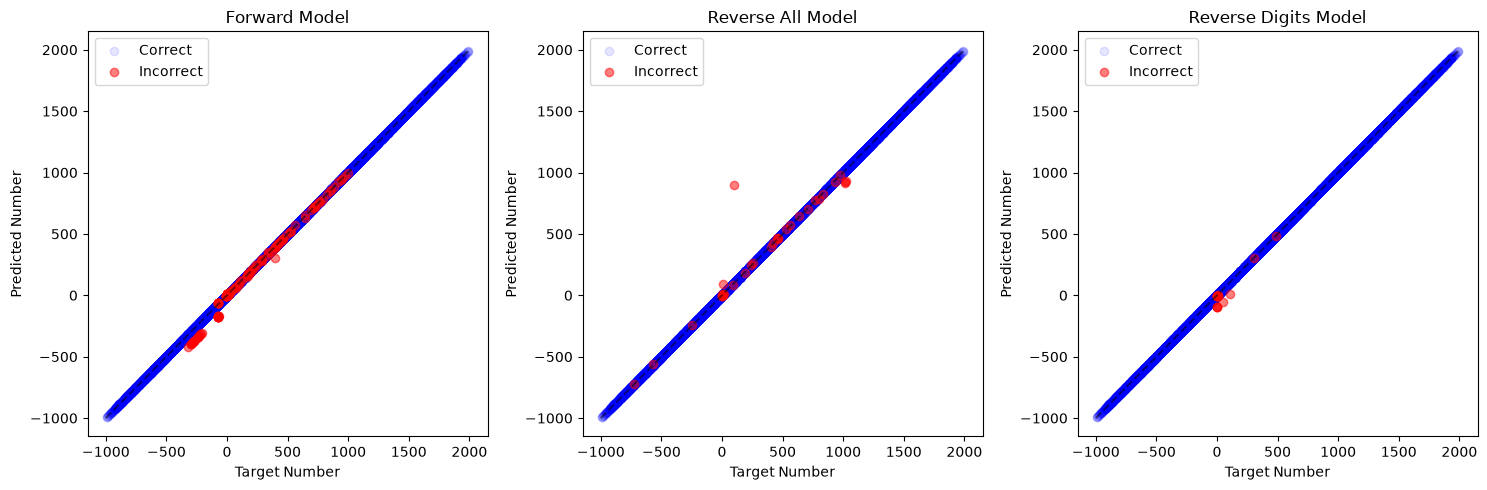

In [13]:
# get target and predicted values
def get_xy(results):
    x_correct,y_correct = [],[]
    x_incorrect,y_incorrect = [],[]

    for r in results:
        if r["pred_value"] is None:
            continue

        if r["correct"]:
            x_correct.append(r["true_value"])
            y_correct.append(r["pred_value"])
        else:
            x_incorrect.append(r["true_value"])
            y_incorrect.append(r["pred_value"])

    return x_correct,y_correct,x_incorrect,y_incorrect

forward_xc,forward_yc,forward_xi,forward_yi = get_xy(results_test_forward)
reverse_all_xc,reverse_all_yc,reverse_all_xi,reverse_all_yi = get_xy(results_test_reverse_all)
reverse_digits_xc,reverse_digits_yc,reverse_digits_xi,reverse_digits_yi = get_xy(results_test_reverse_digits)

# plot target vs predicted values
fig,axes = plt.subplots(1,3,figsize=(15,5))

axes[0].scatter(forward_xc,forward_yc,color='blue',alpha=0.1,label='Correct')
axes[0].scatter(forward_xi,forward_yi,color='red',alpha=0.5,label='Incorrect')
axes[0].plot([-1000,2000],[-1000,2000],'k--',alpha=0.5)
axes[0].set_title('Forward Model')
axes[0].set_xlabel('Target Number')
axes[0].set_ylabel('Predicted Number')
axes[0].legend()

axes[1].scatter(reverse_all_xc,reverse_all_yc,color='blue',alpha=0.1,label='Correct')
axes[1].scatter(reverse_all_xi,reverse_all_yi,color='red',alpha=0.5,label='Incorrect')
axes[1].plot([-1000,2000],[-1000,2000],'k--',alpha=0.5)
axes[1].set_title('Reverse All Model')
axes[1].set_xlabel('Target Number')
axes[1].set_ylabel('Predicted Number')
axes[1].legend()

axes[2].scatter(reverse_digits_xc,reverse_digits_yc,color='blue',alpha=0.1,label='Correct')
axes[2].scatter(reverse_digits_xi,reverse_digits_yi,color='red',alpha=0.5,label='Incorrect')
axes[2].plot([-1000,2000],[-1000,2000],'k--',alpha=0.5)
axes[2].set_title('Reverse Digits Model')
axes[2].set_xlabel('Target Number')
axes[2].set_ylabel('Predicted Number')
axes[2].legend()

plt.tight_layout()
plt.savefig('plot/target_vs_predicted.png')
plt.show()

## Operation Robustness

Comparing how well each model handles Addition vs. Subtraction.

In [14]:
# calculate overall and operation accuracies
def compute_operation_accuracy(results):
    # initialize the correct prediction counters
    overall_correct = 0
    addition_correct = 0
    subtraction_correct = 0

    # initialize the operation counters
    addition_total = 0
    subtraction_total = 0

    # count correct predictions for each operation
    for result in results:
        # count correct predictions across all test examples
        if result["correct"]:
            overall_correct += 1

        # count addition examples and correct predictions
        if result["op"] == "+":
            addition_total += 1
            if result["correct"]:
                addition_correct += 1

        # count subtraction examples and correct predictions
        elif result["op"] == "-":
            subtraction_total += 1
            if result["correct"]:
                subtraction_correct += 1

    # calculate and return the accuracies
    return {
        "Overall":overall_correct/len(results),
        "Addition":addition_correct/addition_total,
        "Subtraction":subtraction_correct/subtraction_total
    }


# calculate the accuracies for each model
operation_accuracy_forward = compute_operation_accuracy(results_test_forward)
operation_accuracy_reverse_all = compute_operation_accuracy(results_test_reverse_all)
operation_accuracy_reverse_digits = compute_operation_accuracy(results_test_reverse_digits)


# print the overall and operation accuracies
print('Operation Robustness')

# print the table header
print(f"{'Model':<18}{'Overall':>12}{'Addition':>14}{'Subtraction':>16}")
print("-"*60)

# print the forward model results
print(f"{'Forward':<18}"
      f"{operation_accuracy_forward['Overall']:>11.2%}"
      f"{operation_accuracy_forward['Addition']:>14.2%}"
      f"{operation_accuracy_forward['Subtraction']:>16.2%}")

# print the reverse all model results
print(f"{'Reverse All':<18}"
      f"{operation_accuracy_reverse_all['Overall']:>11.2%}"
      f"{operation_accuracy_reverse_all['Addition']:>14.2%}"
      f"{operation_accuracy_reverse_all['Subtraction']:>16.2%}")

# print the reverse digits model results
print(f"{'Reverse Digits':<18}"
      f"{operation_accuracy_reverse_digits['Overall']:>11.2%}"
      f"{operation_accuracy_reverse_digits['Addition']:>14.2%}"
      f"{operation_accuracy_reverse_digits['Subtraction']:>16.2%}")

Operation Robustness
Model                  Overall      Addition     Subtraction
------------------------------------------------------------
Forward                99.11%        99.66%          98.57%
Reverse All            99.83%        99.85%          99.82%
Reverse Digits         99.91%       100.00%          99.83%


## Digit-Level Performance

In [15]:
# calculate overall and digit-position accuracy by operation
def compute_digit_level_accuracy(results,operation):
    # initialize the overall correct prediction counter
    overall_correct = 0
    total = 0

    # initialize the correct prediction counter for each digit position
    position_correct = {
        "Thousands":0,
        "Hundreds":0,
        "Tens":0,
        "Units":0
    }

    # evaluate each result for the selected operation
    for result in results:
        # skip results from the other operation
        if result["op"] != operation:
            continue

        total += 1

        # count fully correct predictions
        if result["correct"]:
            overall_correct += 1

        true_value = result["true_value"]
        pred_value = result["pred_value"]

        # convert the true value to four aligned digits without the sign
        true_digits = str(abs(true_value)).zfill(4)

        # skip invalid predictions
        if pred_value is None:
            continue

        # convert the predicted value to four aligned digits without the sign
        pred_digits = str(abs(pred_value)).zfill(4)

        # skip predictions longer than four digits
        if len(pred_digits) != 4:
            continue

        # compare the thousands digit
        if pred_digits[0] == true_digits[0]:
            position_correct["Thousands"] += 1

        # compare the hundreds digit
        if pred_digits[1] == true_digits[1]:
            position_correct["Hundreds"] += 1

        # compare the tens digit
        if pred_digits[2] == true_digits[2]:
            position_correct["Tens"] += 1

        # compare the units digit
        if pred_digits[3] == true_digits[3]:
            position_correct["Units"] += 1

    # calculate and return the overall and digit-position accuracies
    return {
        "Overall":overall_correct/total,
        "Thousands":position_correct["Thousands"]/total,
        "Hundreds":position_correct["Hundreds"]/total,
        "Tens":position_correct["Tens"]/total,
        "Units":position_correct["Units"]/total
    }

In [16]:
# calculate digit-level accuracy for each model and operation
# calculate the forward model accuracies
digit_forward_add = compute_digit_level_accuracy(results_test_forward,"+")
digit_forward_sub = compute_digit_level_accuracy(results_test_forward,"-")

# calculate the reverse all model accuracies
digit_reverse_all_add = compute_digit_level_accuracy(results_test_reverse_all,"+")
digit_reverse_all_sub = compute_digit_level_accuracy(results_test_reverse_all,"-")

# calculate the reverse digits model accuracies
digit_reverse_digits_add = compute_digit_level_accuracy(results_test_reverse_digits,"+")
digit_reverse_digits_sub = compute_digit_level_accuracy(results_test_reverse_digits,"-")

In [17]:
# print the addition digit-level accuracies
print("Addition")

# print the table header
print(f"{'Model':<18}{'Overall':>12}{'Thousands':>12}{'Hundreds':>12}{'Tens':>12}{'Units':>12}")
print("-"*78)

# print the forward model results
print(f"{'Forward':<18}"
      f"{digit_forward_add['Overall']:>11.2%}"
      f"{digit_forward_add['Thousands']:>12.2%}"
      f"{digit_forward_add['Hundreds']:>12.2%}"
      f"{digit_forward_add['Tens']:>12.2%}"
      f"{digit_forward_add['Units']:>12.2%}")

# print the reverse all model results
print(f"{'Reverse All':<18}"
      f"{digit_reverse_all_add['Overall']:>11.2%}"
      f"{digit_reverse_all_add['Thousands']:>12.2%}"
      f"{digit_reverse_all_add['Hundreds']:>12.2%}"
      f"{digit_reverse_all_add['Tens']:>12.2%}"
      f"{digit_reverse_all_add['Units']:>12.2%}")

# print the reverse digits model results
print(f"{'Reverse Digits':<18}"
      f"{digit_reverse_digits_add['Overall']:>11.2%}"
      f"{digit_reverse_digits_add['Thousands']:>12.2%}"
      f"{digit_reverse_digits_add['Hundreds']:>12.2%}"
      f"{digit_reverse_digits_add['Tens']:>12.2%}"
      f"{digit_reverse_digits_add['Units']:>12.2%}")


# print the subtraction digit-level accuracies
print("\nSubtraction")

# print the table header
print(f"{'Model':<18}{'Overall':>12}{'Thousands':>12}{'Hundreds':>12}{'Tens':>12}{'Units':>12}")
print("-"*78)

# print the forward model results
print(f"{'Forward':<18}"
      f"{digit_forward_sub['Overall']:>11.2%}"
      f"{digit_forward_sub['Thousands']:>12.2%}"
      f"{digit_forward_sub['Hundreds']:>12.2%}"
      f"{digit_forward_sub['Tens']:>12.2%}"
      f"{digit_forward_sub['Units']:>12.2%}")

# print the reverse all model results
print(f"{'Reverse All':<18}"
      f"{digit_reverse_all_sub['Overall']:>11.2%}"
      f"{digit_reverse_all_sub['Thousands']:>12.2%}"
      f"{digit_reverse_all_sub['Hundreds']:>12.2%}"
      f"{digit_reverse_all_sub['Tens']:>12.2%}"
      f"{digit_reverse_all_sub['Units']:>12.2%}")

# print the reverse digits model results
print(f"{'Reverse Digits':<18}"
      f"{digit_reverse_digits_sub['Overall']:>11.2%}"
      f"{digit_reverse_digits_sub['Thousands']:>12.2%}"
      f"{digit_reverse_digits_sub['Hundreds']:>12.2%}"
      f"{digit_reverse_digits_sub['Tens']:>12.2%}"
      f"{digit_reverse_digits_sub['Units']:>12.2%}")

Addition
Model                  Overall   Thousands    Hundreds        Tens       Units
------------------------------------------------------------------------------
Forward                99.66%     100.00%      99.99%      99.85%      99.77%
Reverse All            99.85%      99.97%      99.97%      99.88%     100.00%
Reverse Digits        100.00%     100.00%     100.00%     100.00%     100.00%

Subtraction
Model                  Overall   Thousands    Hundreds        Tens       Units
------------------------------------------------------------------------------
Forward                98.57%     100.00%      99.70%      99.82%      99.03%
Reverse All            99.82%     100.00%      99.98%      99.89%      99.94%
Reverse Digits         99.83%     100.00%      99.99%      99.96%      99.85%


In [18]:
# calculate sign accuracy by operation
def compute_sign_accuracy(results,operation):
    # initialize the correct sign counter
    sign_correct = 0
    total = 0

    # evaluate each result for the selected operation
    for result in results:
        # skip results from the other operation
        if result["op"] != operation:
            continue

        total += 1
        true_value = result["true_value"]
        pred_value = result["pred_value"]

        # skip invalid predictions
        if pred_value is None:
            continue

        # compare the predicted and true signs
        if (pred_value < 0) == (true_value < 0):
            sign_correct += 1

    # calculate and return the sign accuracy
    return sign_correct/total


# calculate sign accuracy for each model and operation

# calculate the forward model sign accuracies
sign_forward_add = compute_sign_accuracy(results_test_forward,"+")
sign_forward_sub = compute_sign_accuracy(results_test_forward,"-")

# calculate the reverse all model sign accuracies
sign_reverse_all_add = compute_sign_accuracy(results_test_reverse_all,"+")
sign_reverse_all_sub = compute_sign_accuracy(results_test_reverse_all,"-")

# calculate the reverse digits model sign accuracies
sign_reverse_digits_add = compute_sign_accuracy(results_test_reverse_digits,"+")
sign_reverse_digits_sub = compute_sign_accuracy(results_test_reverse_digits,"-")


# print the sign accuracies
print("\nSign Accuracy")

# print the table header
print(f"{'Model':<18}{'Addition':>14}{'Subtraction':>16}")
print("-"*48)

# print the forward model results
print(f"{'Forward':<18}"
      f"{sign_forward_add:>14.2%}"
      f"{sign_forward_sub:>16.2%}")

# print the reverse all model results
print(f"{'Reverse All':<18}"
      f"{sign_reverse_all_add:>14.2%}"
      f"{sign_reverse_all_sub:>16.2%}")

# print the reverse digits model results
print(f"{'Reverse Digits':<18}"
      f"{sign_reverse_digits_add:>14.2%}"
      f"{sign_reverse_digits_sub:>16.2%}")


Sign Accuracy
Model                   Addition     Subtraction
------------------------------------------------
Forward                  100.00%         100.00%
Reverse All              100.00%          99.96%
Reverse Digits           100.00%          99.86%


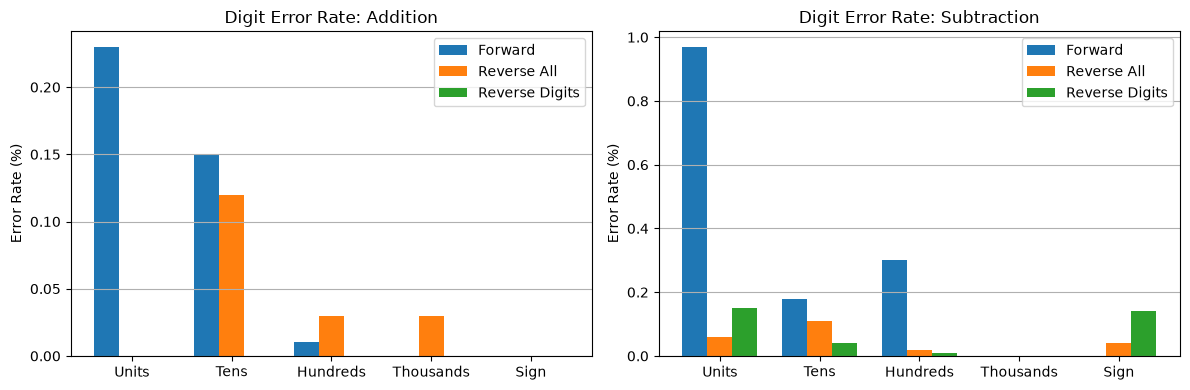

In [19]:
# prepare digit and sign accuracies for plotting
x_labels = ["Units","Tens","Hundreds","Thousands","Sign"]

# prepare the addition accuracies for each model
forward_add = [digit_forward_add["Units"],digit_forward_add["Tens"],digit_forward_add["Hundreds"],digit_forward_add["Thousands"],sign_forward_add]
reverse_all_add = [digit_reverse_all_add["Units"],digit_reverse_all_add["Tens"],digit_reverse_all_add["Hundreds"],digit_reverse_all_add["Thousands"],sign_reverse_all_add]
reverse_digits_add = [digit_reverse_digits_add["Units"],digit_reverse_digits_add["Tens"],digit_reverse_digits_add["Hundreds"],digit_reverse_digits_add["Thousands"],sign_reverse_digits_add]

# prepare the subtraction accuracies for each model
forward_sub = [digit_forward_sub["Units"],digit_forward_sub["Tens"],digit_forward_sub["Hundreds"],digit_forward_sub["Thousands"],sign_forward_sub]
reverse_all_sub = [digit_reverse_all_sub["Units"],digit_reverse_all_sub["Tens"],digit_reverse_all_sub["Hundreds"],digit_reverse_all_sub["Thousands"],sign_reverse_all_sub]
reverse_digits_sub = [digit_reverse_digits_sub["Units"],digit_reverse_digits_sub["Tens"],digit_reverse_digits_sub["Hundreds"],digit_reverse_digits_sub["Thousands"],sign_reverse_digits_sub]

# convert the addition accuracies to error rates
forward_add_error = [(1-x)*100 for x in forward_add]
reverse_all_add_error = [(1-x)*100 for x in reverse_all_add]
reverse_digits_add_error = [(1-x)*100 for x in reverse_digits_add]

# convert the subtraction accuracies to error rates
forward_sub_error = [(1-x)*100 for x in forward_sub]
reverse_all_sub_error = [(1-x)*100 for x in reverse_all_sub]
reverse_digits_sub_error = [(1-x)*100 for x in reverse_digits_sub]

# set the bar positions and width
x = np.arange(len(x_labels))
width = 0.25

# create the addition and subtraction plots
fig,axes = plt.subplots(1,2,figsize=(12,4))

# plot the addition error rates
axes[0].bar(x-width,forward_add_error,width,label='Forward')
axes[0].bar(x,reverse_all_add_error,width,label='Reverse All')
axes[0].bar(x+width,reverse_digits_add_error,width,label='Reverse Digits')

# set the addition plot labels and title
axes[0].set_title('Digit Error Rate: Addition')
axes[0].set_xticks(x)
axes[0].set_xticklabels(x_labels)
axes[0].set_ylabel('Error Rate (%)')
axes[0].grid(axis='y')
axes[0].legend()

# plot the subtraction error rates
axes[1].bar(x-width,forward_sub_error,width,label='Forward')
axes[1].bar(x,reverse_all_sub_error,width,label='Reverse All')
axes[1].bar(x+width,reverse_digits_sub_error,width,label='Reverse Digits')

# set the subtraction plot labels and title
axes[1].set_title('Digit Error Rate: Subtraction')
axes[1].set_xticks(x)
axes[1].set_xticklabels(x_labels)
axes[1].set_ylabel('Error Rate (%)')
axes[1].grid(axis='y')
axes[1].legend()

# save and display the plots
plt.tight_layout()
plt.savefig('plot/digit_error_rate.png')
plt.show()

## Direction Effects

In [20]:
# calculate accuracy changes from the forward model
direction_effects = {
    # compare the overall accuracy
    "Overall":[
        operation_accuracy_reverse_all["Overall"]-operation_accuracy_forward["Overall"],
        operation_accuracy_reverse_digits["Overall"]-operation_accuracy_forward["Overall"]
    ],

    # compare the addition accuracy
    "Addition":[
        operation_accuracy_reverse_all["Addition"]-operation_accuracy_forward["Addition"],
        operation_accuracy_reverse_digits["Addition"]-operation_accuracy_forward["Addition"]
    ],

    # compare the subtraction accuracy
    "Subtraction":[
        operation_accuracy_reverse_all["Subtraction"]-operation_accuracy_forward["Subtraction"],
        operation_accuracy_reverse_digits["Subtraction"]-operation_accuracy_forward["Subtraction"]
    ],

    # compare the addition sign accuracy
    "Addition Sign":[
        sign_reverse_all_add-sign_forward_add,
        sign_reverse_digits_add-sign_forward_add
    ],

    # compare the subtraction sign accuracy
    "Subtraction Sign":[
        sign_reverse_all_sub-sign_forward_sub,
        sign_reverse_digits_sub-sign_forward_sub
    ]
}

# print the direction effects
print('Direction Effects')

# print the table header
print(f"{'Metric':<20}{'Reverse All - Forward':>24}{'Reverse Digits - Forward':>28}")
print("-"*72)

# print the accuracy changes in percentage points
for metric in direction_effects:
    print(f"{metric:<20}"
          f"{direction_effects[metric][0]*100:>+23.2f} pp"
          f"{direction_effects[metric][1]*100:>+27.2f} pp")

Direction Effects
Metric                 Reverse All - Forward    Reverse Digits - Forward
------------------------------------------------------------------------
Overall                               +0.72 pp                      +0.80 pp
Addition                              +0.19 pp                      +0.34 pp
Subtraction                           +1.25 pp                      +1.26 pp
Addition Sign                         +0.00 pp                      +0.00 pp
Subtraction Sign                      -0.04 pp                      -0.14 pp


## Error Patterns

### Carry / Borrow

In [21]:
# check whether addition has carry
def has_carry(prompt):
    # separate the two operands and align them to three digits
    a,b = prompt[:-1].split("+")
    a = a.zfill(3)
    b = b.zfill(3)

    # check each digit from units to hundreds
    carry = 0
    for i in range(2,-1,-1):
        # return true if a carry occurs
        if int(a[i])+int(b[i])+carry >= 10:
            return True
        carry = 0

    # return false if no carry occurs
    return False


# check whether subtraction has borrow
def has_borrow(prompt):
    # separate the two operands and align them to three digits
    a,b = prompt[:-1].split("-")
    a = a.zfill(3)
    b = b.zfill(3)

    # check each digit from units to hundreds
    borrow = 0
    for i in range(2,-1,-1):
        digit_a = int(a[i])-borrow
        digit_b = int(b[i])

        # return true if a borrow occurs
        if digit_a < digit_b:
            return True

        borrow = 0

    # return false if no borrow occurs
    return False

In [22]:
# calculate error rates for carry and borrow cases
def compute_carry_borrow_error(results):
    # initialize the addition counters
    carry_correct = 0
    carry_total = 0
    no_carry_correct = 0
    no_carry_total = 0

    # initialize the subtraction counters
    borrow_correct = 0
    borrow_total = 0
    no_borrow_correct = 0
    no_borrow_total = 0

    # classify each result by carry or borrow
    for r in results:
        # classify addition cases
        if r["op"] == "+":
            if has_carry(r["prompt"]):
                carry_total += 1
                if r["correct"]:
                    carry_correct += 1
            else:
                no_carry_total += 1
                if r["correct"]:
                    no_carry_correct += 1

        # classify subtraction cases
        elif r["op"] == "-":
            if has_borrow(r["prompt"]):
                borrow_total += 1
                if r["correct"]:
                    borrow_correct += 1
            else:
                no_borrow_total += 1
                if r["correct"]:
                    no_borrow_correct += 1

    # calculate and return the error rates
    return {
        "Carry":1-carry_correct/carry_total,
        "No Carry":1-no_carry_correct/no_carry_total,
        "Borrow":1-borrow_correct/borrow_total,
        "No Borrow":1-no_borrow_correct/no_borrow_total
    }

In [23]:
# calculate carry and borrow error rates
carry_borrow_forward = compute_carry_borrow_error(results_test_forward)
carry_borrow_reverse_all = compute_carry_borrow_error(results_test_reverse_all)
carry_borrow_reverse_digits = compute_carry_borrow_error(results_test_reverse_digits)

In [24]:
# print the carry and borrow error rates
print('Carry and Borrow Error Rates')

# print the table header
print(f"{'Model':<18}{'Carry':>12}{'No Carry':>12}{'Borrow':>12}{'No Borrow':>12}")
print("-"*66)

# print the forward model results
print(f"{'Forward':<18}"
      f"{carry_borrow_forward['Carry']*100:>11.2f}%"
      f"{carry_borrow_forward['No Carry']*100:>11.2f}%"
      f"{carry_borrow_forward['Borrow']*100:>11.2f}%"
      f"{carry_borrow_forward['No Borrow']*100:>11.2f}%")

# print the reverse all model results
print(f"{'Reverse All':<18}"
      f"{carry_borrow_reverse_all['Carry']*100:>11.2f}%"
      f"{carry_borrow_reverse_all['No Carry']*100:>11.2f}%"
      f"{carry_borrow_reverse_all['Borrow']*100:>11.2f}%"
      f"{carry_borrow_reverse_all['No Borrow']*100:>11.2f}%")

# print the reverse digits model results
print(f"{'Reverse Digits':<18}"
      f"{carry_borrow_reverse_digits['Carry']*100:>11.2f}%"
      f"{carry_borrow_reverse_digits['No Carry']*100:>11.2f}%"
      f"{carry_borrow_reverse_digits['Borrow']*100:>11.2f}%"
      f"{carry_borrow_reverse_digits['No Borrow']*100:>11.2f}%")

Carry and Borrow Error Rates
Model                    Carry    No Carry      Borrow   No Borrow
------------------------------------------------------------------
Forward                  0.24%       0.84%       1.05%       3.26%
Reverse All              0.16%       0.12%       0.11%       0.52%
Reverse Digits           0.00%       0.00%       0.02%       0.87%


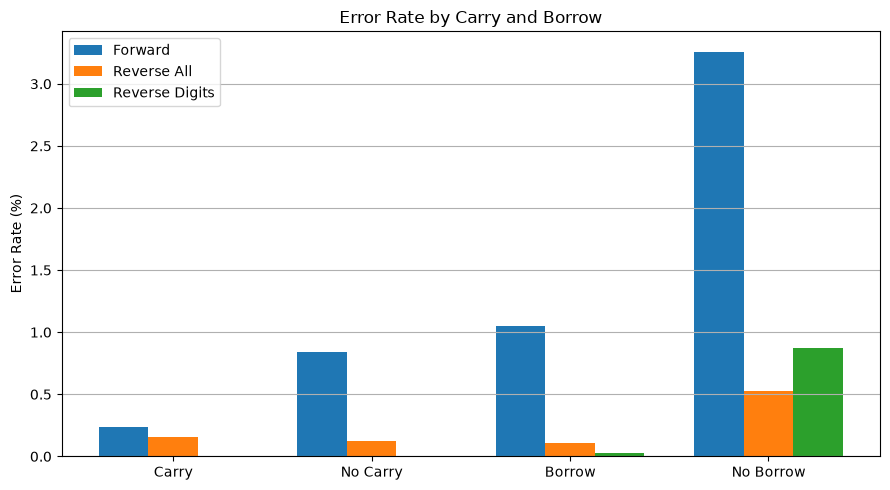

In [25]:
# define the carry and borrow categories
labels = ["Carry","No Carry","Borrow","No Borrow"]

# convert the error rates to percentages for each model
forward_error = [carry_borrow_forward[x]*100 for x in labels]
reverse_all_error = [carry_borrow_reverse_all[x]*100 for x in labels]
reverse_digits_error = [carry_borrow_reverse_digits[x]*100 for x in labels]

# set the bar positions and width
x = np.arange(len(labels))
width = 0.25

# create the carry and borrow error rate plot
plt.figure(figsize=(9,5))

# plot the error rates for each prediction mode
plt.bar(x-width,forward_error,width,label='Forward')
plt.bar(x,reverse_all_error,width,label='Reverse All')
plt.bar(x+width,reverse_digits_error,width,label='Reverse Digits')

# set the plot labels and title
plt.xticks(x,labels)
plt.ylabel('Error Rate (%)')
plt.title('Error Rate by Carry and Borrow')
plt.grid(axis='y')
plt.legend()

# save and display the plot
plt.tight_layout()
plt.savefig('plot/carry_borrow_error_rate.png')
plt.show()

In [26]:
# print incorrect carry and borrow samples from the test set
def print_incorrect_carry_borrow_samples(results_forward,results_reverse_all,results_reverse_digits,n=5):
    # create lookup tables for each model
    forward_lookup = {r["prompt"]:r for r in results_forward}
    reverse_all_lookup = {r["prompt"]:r for r in results_reverse_all}
    reverse_digits_lookup = {r["prompt"]:r for r in results_reverse_digits}

    # collect carry and borrow cases where any model is incorrect
    carry_samples = []
    borrow_samples = []

    for prompt in forward_lookup:
        forward = forward_lookup[prompt]
        reverse_all = reverse_all_lookup[prompt]
        reverse_digits = reverse_digits_lookup[prompt]

        # check whether any model made an incorrect prediction
        if forward["correct"] and reverse_all["correct"] and reverse_digits["correct"]:
            continue

        # collect addition cases with carry
        if forward["op"] == "+" and has_carry(prompt):
            carry_samples.append(prompt)

        # collect subtraction cases with borrow
        elif forward["op"] == "-" and has_borrow(prompt):
            borrow_samples.append(prompt)

    # print the carry cases
    print("\nIncorrect Carry Samples")
    print(f"{'Prompt':<14}| {'Expected':<10}| {'Forward':<12}| {'Reverse All':<12}| {'Reverse Digits':<14}")
    print("-"*72)

    for prompt in carry_samples[:n]:
        forward = forward_lookup[prompt]
        reverse_all = reverse_all_lookup[prompt]
        reverse_digits = reverse_digits_lookup[prompt]

        print(f"{prompt:<14}| "
              f"{forward['true_ans']:<10}| "
              f"{forward['pred_ans']:<12}| "
              f"{reverse_all['pred_ans']:<12}| "
              f"{reverse_digits['pred_ans']:<14}")

    # print the borrow cases
    print("\nIncorrect Borrow Samples")
    print(f"{'Prompt':<14}| {'Expected':<10}| {'Forward':<12}| {'Reverse All':<12}| {'Reverse Digits':<14}")
    print("-"*72)

    for prompt in borrow_samples[:n]:
        forward = forward_lookup[prompt]
        reverse_all = reverse_all_lookup[prompt]
        reverse_digits = reverse_digits_lookup[prompt]

        print(f"{prompt:<14}| "
              f"{forward['true_ans']:<10}| "
              f"{forward['pred_ans']:<12}| "
              f"{reverse_all['pred_ans']:<12}| "
              f"{reverse_digits['pred_ans']:<14}")

In [27]:
# show incorrect carry and borrow examples
print_incorrect_carry_borrow_samples(
    results_test_forward,
    results_test_reverse_all,
    results_test_reverse_digits,
    n=10
)


Incorrect Carry Samples
Prompt        | Expected  | Forward     | Reverse All | Reverse Digits
------------------------------------------------------------------------
56+114=       | 170       | 160         | 170         | 170           
66+7=         | 73        | 63          | 73          | 73            
276+8=        | 284       | 285         | 284         | 284           
765+6=        | 771       | 761         | 771         | 771           
386+7=        | 393       | 383         | 393         | 393           
361+9=        | 370       | 360         | 370         | 370           
370+657=      | 1027      | 1027        | 927         | 1027          
408+9=        | 417       | 418         | 427         | 417           
925+7=        | 932       | 932         | 922         | 932           
326+4=        | 330       | 320         | 330         | 330           

Incorrect Borrow Samples
Prompt        | Expected  | Forward     | Reverse All | Reverse Digits
------------------------

In [28]:
# collect borrow cases where the reverse digits model is incorrect
reverse_digits_borrow_errors = []

# create lookup tables for the other models
forward_lookup = {r["prompt"]:r for r in results_test_forward}
reverse_all_lookup = {r["prompt"]:r for r in results_test_reverse_all}

# select incorrect borrow cases from the reverse digits model
for r in results_test_reverse_digits:
    if r["op"] == "-" and has_borrow(r["prompt"]) and not r["correct"]:
        reverse_digits_borrow_errors.append(r)


# print incorrect reverse digits borrow samples
print("\nReverse Digits - Incorrect Borrow Samples")

# print the table header
print(f"{'Prompt':<14}| {'Expected':<10}| {'Forward':<12}| {'Reverse All':<12}| {'Reverse Digits':<14}")
print("-"*72)

# print the first ten incorrect samples
for r in reverse_digits_borrow_errors[:10]:
    prompt = r["prompt"]

    forward = forward_lookup[prompt]
    reverse_all = reverse_all_lookup[prompt]

    print(f"{prompt:<14}| "
          f"{r['true_ans']:<10}| "
          f"{forward['pred_ans']:<12}| "
          f"{reverse_all['pred_ans']:<12}| "
          f"{r['pred_ans']:<14}")


Reverse Digits - Incorrect Borrow Samples
Prompt        | Expected  | Forward     | Reverse All | Reverse Digits
------------------------------------------------------------------------
53-6=         | 47        | 47          | 47          | -53           
117-8=        | 109       | 119         | 109         | 9             



Prompt: 53-6=
Expected: 47
Stored Prediction: -53
Raw Prediction: -35
Restored Prediction: -53


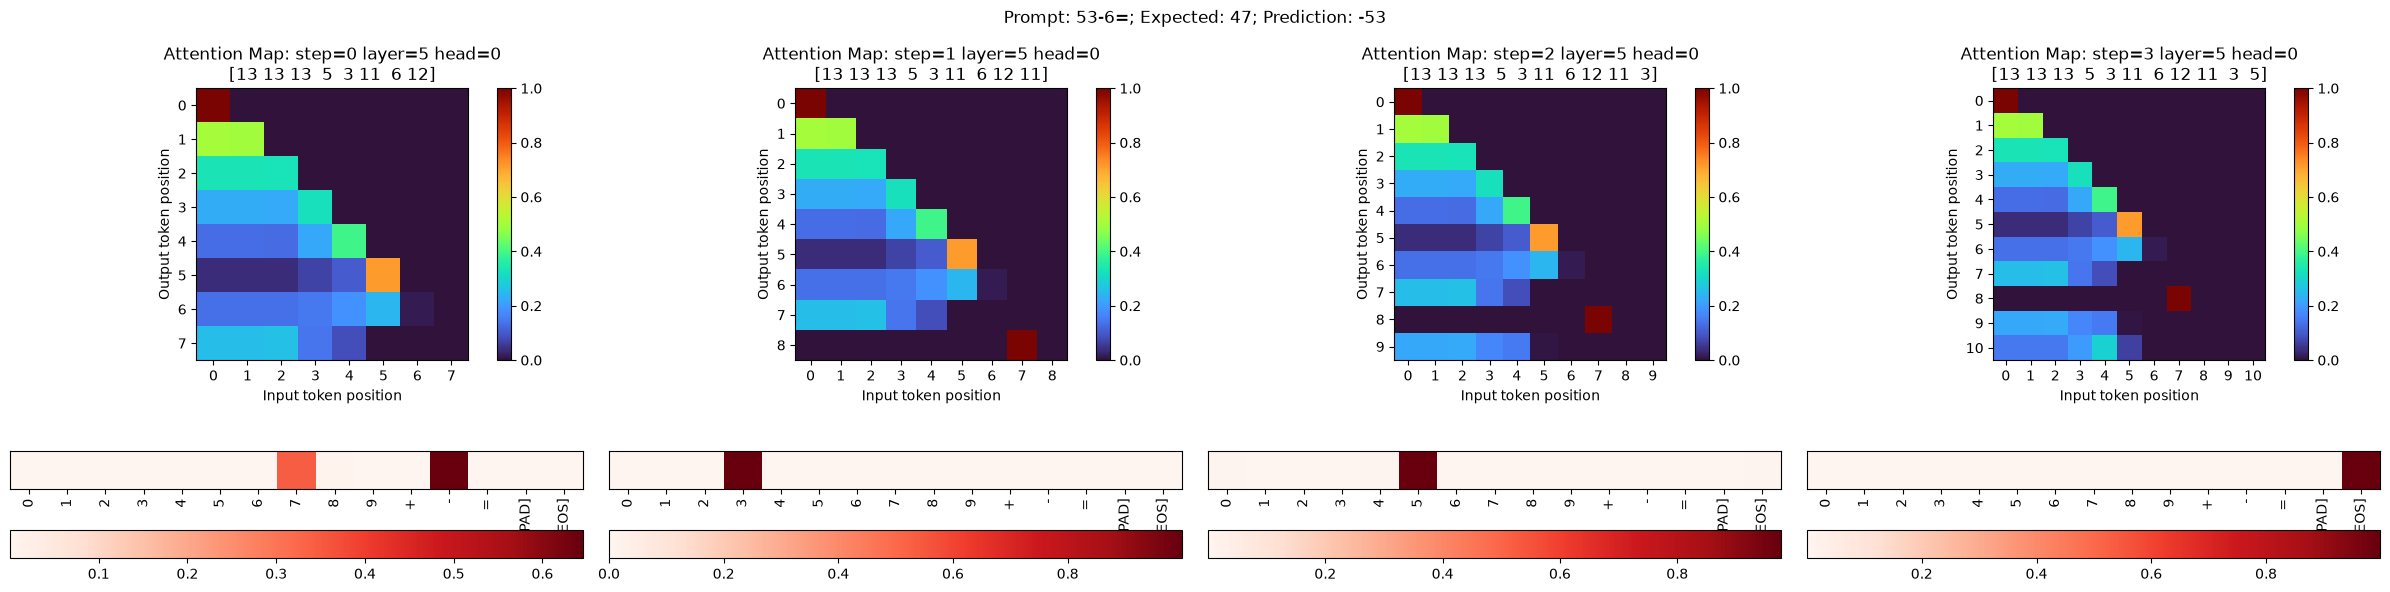


Prompt: 117-8=
Expected: 109
Stored Prediction: 9
Raw Prediction: 9
Restored Prediction: 9


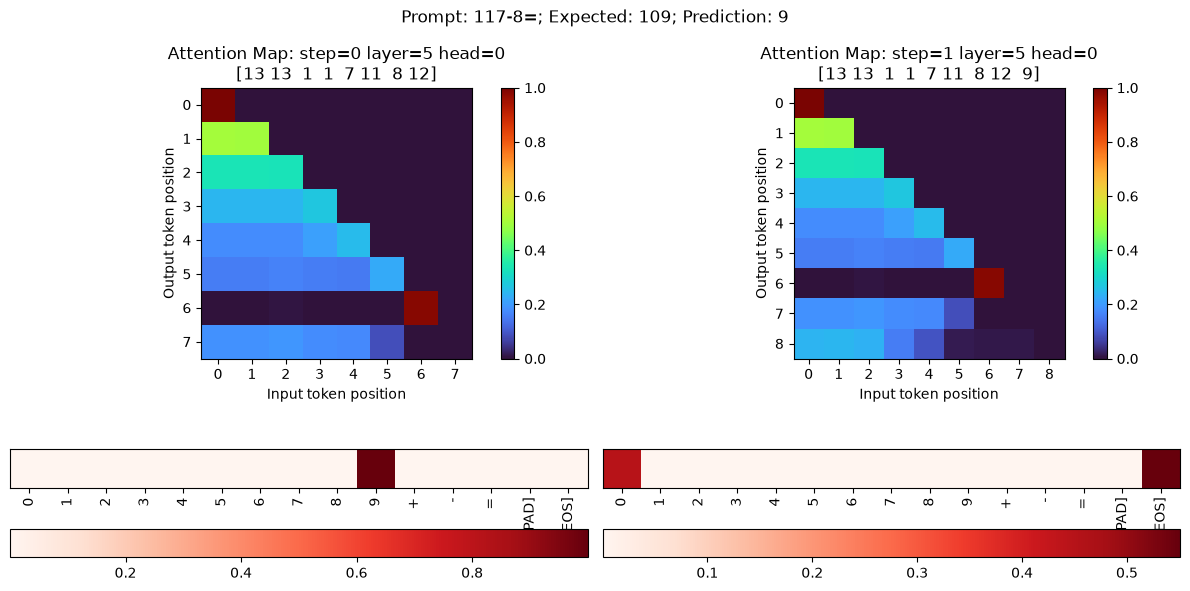

In [40]:
model = model_reverse_digits
model.eval()

layer, attn_head = 5, 0

# check the two incorrect borrow cases
for sample in reverse_digits_borrow_errors[:2]:

    prompt = sample["prompt"]
    answer = sample["true_ans"]

    # use the same left padding used during evaluation
    encoded_prompt = tokenizer.encode(prompt)
    padded_prompt = (
        [tokenizer.token_to_id[pad_token]]*(8-len(encoded_prompt))
        + encoded_prompt
    )

    input_tensor = torch.tensor(
        padded_prompt
    ).view((-1,1)).to(device)

    attn_maps_list = []
    vocab_pred = []

    for step in range(6):

        output,_,attention_maps = model(input_tensor)

        # save attention map
        attn_maps_list.append(
            attention_maps[layer][0,attn_head]
            .detach()
            .cpu()
            .numpy()
        )

        # get predicted next token
        last_output = output[-1,:,:]

        vocab_pred.append(
            torch.exp(last_output)
            .detach()
            .cpu()
            .numpy()
            .ravel()
        )

        token = torch.argmax(
            last_output,-1
        ).view(1,-1)

        # append predicted token
        input_tensor = torch.cat(
            (input_tensor,token),
            dim=0
        )

        # stop at EOS
        if token.item() == tokenizer.token_to_id[eos_token]:
            break

    input_tensor = input_tensor.detach().cpu().numpy().ravel()

    # extract generated tokens
    pred_tokens = input_tensor[8:].tolist()

    if tokenizer.token_to_id[eos_token] in pred_tokens:
        eos_idx = pred_tokens.index(
            tokenizer.token_to_id[eos_token]
        )
        pred_tokens = pred_tokens[:eos_idx]

    raw_prediction = tokenizer.decode(pred_tokens)
    restored_prediction = restore_answer(
        raw_prediction,
        "reverse_digits"
    )

    print()
    print("Prompt:",prompt)
    print("Expected:",answer)
    print("Stored Prediction:",sample["pred_ans"])
    print("Raw Prediction:",raw_prediction)
    print("Restored Prediction:",restored_prediction)

    fig,axes = plt.subplots(
        nrows=2,
        ncols=len(attn_maps_list),
        figsize=(6*len(attn_maps_list),6)
    )

    if len(attn_maps_list) == 1:
        axes = axes.reshape(2,1)

    for s,(attn,vp) in enumerate(
        zip(attn_maps_list,vocab_pred)
    ):

        axes[0,s].imshow(
            attn,
            cmap="turbo"
        )

        axes[0,s].set_title(
            f"Attention Map: step={s} "
            f"layer={layer} head={attn_head}\n"
            f"{input_tensor[:8+s]}"
        )

        axes[0,s].set_xlabel(
            "Input token position"
        )
        axes[0,s].set_xticks(
            np.arange(attn.shape[0])
        )

        axes[0,s].set_ylabel(
            "Output token position"
        )
        axes[0,s].set_yticks(
            np.arange(attn.shape[0])
        )

        plt.colorbar(
            axes[0,s].images[0],
            ax=axes[0,s]
        )

        axes[1,s].imshow(
            vp.reshape(1,-1),
            cmap="Reds"
        )

        plt.colorbar(
            axes[1,s].images[0],
            ax=axes[1,s],
            orientation="horizontal"
        )

        axes[1,s].set_xlabel("Vocabulary")
        axes[1,s].set_xticks(
            np.arange(len(vp))
        )
        axes[1,s].set_xticklabels(
            tokenizer.vocab,
            rotation=90
        )
        axes[1,s].set_yticks([])

    plt.suptitle(
        f"Prompt: {prompt}; "
        f"Expected: {answer}; "
        f"Prediction: {restored_prediction}"
    )

    plt.tight_layout()
    plt.show()

### Result Length

In [29]:
# calculate error rates by result length
def compute_result_length_error(results):
    # initialize the counters for each result length
    correct = {
        "1 Digit":0,
        "2 Digits":0,
        "3 Digits":0,
        "4 Digits":0
    }

    total = {
        "1 Digit":0,
        "2 Digits":0,
        "3 Digits":0,
        "4 Digits":0
    }

    # classify each result by the number of digits
    for r in results:
        result_length = len(str(abs(r["true_value"])))

        # create the result length label
        if result_length == 1:
            label = "1 Digit"
        elif result_length == 2:
            label = "2 Digits"
        elif result_length == 3:
            label = "3 Digits"
        elif result_length == 4:
            label = "4 Digits"
        else:
            continue

        # count the total and correct predictions
        total[label] += 1

        if r["correct"]:
            correct[label] += 1

    # calculate and return the error rates
    return {
        label:1-correct[label]/total[label]
        for label in total
        if total[label] > 0
    }

In [30]:
# calculate result length error rates for each model
result_length_forward = compute_result_length_error(results_test_forward)
result_length_reverse_all = compute_result_length_error(results_test_reverse_all)
result_length_reverse_digits = compute_result_length_error(results_test_reverse_digits)

In [31]:
# print the result length error rates
print("Result Length Error Rates")

# print the table header
print(f"{'Model':<18}{'1 Digit':>12}{'2 Digits':>12}{'3 Digits':>12}{'4 Digits':>12}")
print("-"*66)

# print the forward model results
print(f"{'Forward':<18}"
      f"{result_length_forward.get('1 Digit',0)*100:>11.2f}%"
      f"{result_length_forward.get('2 Digits',0)*100:>11.2f}%"
      f"{result_length_forward.get('3 Digits',0)*100:>11.2f}%"
      f"{result_length_forward.get('4 Digits',0)*100:>11.2f}%")

# print the reverse all model results
print(f"{'Reverse All':<18}"
      f"{result_length_reverse_all.get('1 Digit',0)*100:>11.2f}%"
      f"{result_length_reverse_all.get('2 Digits',0)*100:>11.2f}%"
      f"{result_length_reverse_all.get('3 Digits',0)*100:>11.2f}%"
      f"{result_length_reverse_all.get('4 Digits',0)*100:>11.2f}%")

# print the reverse digits model results
print(f"{'Reverse Digits':<18}"
      f"{result_length_reverse_digits.get('1 Digit',0)*100:>11.2f}%"
      f"{result_length_reverse_digits.get('2 Digits',0)*100:>11.2f}%"
      f"{result_length_reverse_digits.get('3 Digits',0)*100:>11.2f}%"
      f"{result_length_reverse_digits.get('4 Digits',0)*100:>11.2f}%")

Result Length Error Rates
Model                  1 Digit    2 Digits    3 Digits    4 Digits
------------------------------------------------------------------
Forward                 37.71%       1.63%       0.62%       0.00%
Reverse All              3.43%       0.22%       0.15%       0.06%
Reverse Digits           7.43%       0.05%       0.02%       0.00%


### Asymmetric Operand Lengths

In [32]:
# calculate error rates by operand length symmetry
def compute_operand_length_error(results):
    # initialize the counters
    same_correct = 0
    same_total = 0
    different_correct = 0
    different_total = 0

    # classify each result by operand length
    for r in results:
        prompt = r["prompt"][:-1]

        # separate the two operands
        if r["op"] == "+":
            a,b = prompt.split("+")
        else:
            a,b = prompt.split("-")

        # count cases with the same operand length
        if len(a) == len(b):
            same_total += 1

            if r["correct"]:
                same_correct += 1

        # count cases with different operand lengths
        else:
            different_total += 1

            if r["correct"]:
                different_correct += 1

    # calculate and return the error rates
    return {
        "Same Length":1-same_correct/same_total,
        "Different Length":1-different_correct/different_total
    }

In [33]:
# calculate operand length error rates for each model
operand_length_forward = compute_operand_length_error(results_test_forward)
operand_length_reverse_all = compute_operand_length_error(results_test_reverse_all)
operand_length_reverse_digits = compute_operand_length_error(results_test_reverse_digits)

In [34]:
# print the operand length error rates
print("Operand Length Error Rates")

# print the table header
print(f"{'Model':<18}{'Same Length':>16}{'Different Length':>20}")
print("-"*54)

# print the forward model results
print(f"{'Forward':<18}"
      f"{operand_length_forward['Same Length']*100:>15.2f}%"
      f"{operand_length_forward['Different Length']*100:>19.2f}%")

# print the reverse all model results
print(f"{'Reverse All':<18}"
      f"{operand_length_reverse_all['Same Length']*100:>15.2f}%"
      f"{operand_length_reverse_all['Different Length']*100:>19.2f}%")

# print the reverse digits model results
print(f"{'Reverse Digits':<18}"
      f"{operand_length_reverse_digits['Same Length']*100:>15.2f}%"
      f"{operand_length_reverse_digits['Different Length']*100:>19.2f}%")

Operand Length Error Rates
Model                  Same Length    Different Length
------------------------------------------------------
Forward                      0.49%               2.67%
Reverse All                  0.09%               0.52%
Reverse Digits               0.08%               0.11%


### Crossing Zero

In [35]:
# calculate error rates by subtraction result sign
def compute_crossing_zero_error(results):
    # initialize the counters
    negative_correct = 0
    negative_total = 0
    non_negative_correct = 0
    non_negative_total = 0

    # check only subtraction results
    for r in results:
        if r["op"] == "-":

            # classify negative results
            if r["true_value"] < 0:
                negative_total += 1

                if r["correct"]:
                    negative_correct += 1

            # classify non-negative results
            else:
                non_negative_total += 1

                if r["correct"]:
                    non_negative_correct += 1

    # calculate and return the error rates
    return {
        "Negative":1-negative_correct/negative_total,
        "Non-negative":1-non_negative_correct/non_negative_total
    }


# calculate sign accuracy for subtraction results
def compute_subtraction_sign_accuracy(results):
    # initialize the counters
    negative_correct = 0
    negative_total = 0
    non_negative_correct = 0
    non_negative_total = 0

    # check only subtraction results
    for r in results:
        if r["op"] == "-":

            # check negative results
            if r["true_value"] < 0:
                negative_total += 1

                # count the sign as correct if the prediction is negative
                if r["pred_value"] is not None and r["pred_value"] < 0:
                    negative_correct += 1

            # check non-negative results
            else:
                non_negative_total += 1

                # count the sign as correct if the prediction is non-negative
                if r["pred_value"] is not None and r["pred_value"] >= 0:
                    non_negative_correct += 1

    # calculate and return the sign accuracies
    return {
        "Negative":negative_correct/negative_total,
        "Non-negative":non_negative_correct/non_negative_total
    }


# calculate error rates for each model
crossing_zero_forward = compute_crossing_zero_error(results_test_forward)
crossing_zero_reverse_all = compute_crossing_zero_error(results_test_reverse_all)
crossing_zero_reverse_digits = compute_crossing_zero_error(results_test_reverse_digits)

# calculate sign accuracy for each model
sign_accuracy_forward = compute_subtraction_sign_accuracy(results_test_forward)
sign_accuracy_reverse_all = compute_subtraction_sign_accuracy(results_test_reverse_all)
sign_accuracy_reverse_digits = compute_subtraction_sign_accuracy(results_test_reverse_digits)


# print the subtraction error rates and sign accuracies
print("Subtraction Error Rates and Sign Accuracy by Result Sign")

# print the table header
print(f"{'Model':<18}"
      f"{'Negative Error Rate':>22}"
      f"{'Non-neg Error Rate':>20}"
      f"{'Negative Sign Acc.':>20}"
      f"{'Non-neg Sign Acc.':>20}")
print("-"*100)

# print the forward model results
print(f"{'Forward':<18}"
      f"{crossing_zero_forward['Negative']*100:>21.2f}%"
      f"{crossing_zero_forward['Non-negative']*100:>19.2f}%"
      f"{sign_accuracy_forward['Negative']*100:>19.2f}%"
      f"{sign_accuracy_forward['Non-negative']*100:>19.2f}%")

# print the reverse all model results
print(f"{'Reverse All':<18}"
      f"{crossing_zero_reverse_all['Negative']*100:>21.2f}%"
      f"{crossing_zero_reverse_all['Non-negative']*100:>19.2f}%"
      f"{sign_accuracy_reverse_all['Negative']*100:>19.2f}%"
      f"{sign_accuracy_reverse_all['Non-negative']*100:>19.2f}%")

# print the reverse digits model results
print(f"{'Reverse Digits':<18}"
      f"{crossing_zero_reverse_digits['Negative']*100:>21.2f}%"
      f"{crossing_zero_reverse_digits['Non-negative']*100:>19.2f}%"
      f"{sign_accuracy_reverse_digits['Negative']*100:>19.2f}%"
      f"{sign_accuracy_reverse_digits['Non-negative']*100:>19.2f}%")

Subtraction Error Rates and Sign Accuracy by Result Sign
Model                Negative Error Rate  Non-neg Error Rate  Negative Sign Acc.   Non-neg Sign Acc.
----------------------------------------------------------------------------------------------------
Forward                            0.94%               1.91%             100.00%             100.00%
Reverse All                        0.08%               0.28%              99.98%              99.94%
Reverse Digits                     0.00%               0.34%             100.00%              99.72%


# Additional Analysis

## Length Generalization (Out-of-Distribution)

Does the LLM actually learn the general mathematical algorithm, or just memorize 3-digit length patterns? We test the model on 4-digit and 5-digit arithmetic which it has never seen during training.

In [68]:
# define out-of-distribution 4-digit and 5-digit arithmetic examples
ood_prompts = [
    ("1000+2000=","3000"),
    ("9999+1=","10000"),
    ("12345+54321=","66666"),
    ("5000-1000=","4000"),
    ("9999-9999=","0"),
    ("1111+2222=","3333"),
    ("8888-4444=","4444"),
    ("10000+20000=","30000"),
    ("7777+3333=","11110"),
    ("50000-1=","49999")
]

# print the OOD prediction table
print("Out-of-Distribution Length Generalization\n")

# print the table header
print(f"{'Prompt':<16}| {'Expected':<12}| {'Forward':<14}| {'Reverse All':<14}| {'Reverse Digits':<14}")
print("-"*82)

# evaluate each OOD example
for prompt,true_ans in ood_prompts:
    # encode the prompt without additional padding
    encoded_prompt = tokenizer.encode(prompt)
    prompt_length = len(encoded_prompt)
    X = torch.tensor([encoded_prompt],dtype=torch.long).transpose(0,1).to(device)

    # generate the forward prediction
    input_tensor_forward = X.clone()

    for _ in range(7):
        output,_,_ = model_forward(input_tensor_forward)
        token = torch.argmax(output[-1,:,:],-1).view(1,-1)
        input_tensor_forward = torch.cat((input_tensor_forward,token),0)

    pred_tokens_forward = input_tensor_forward[prompt_length:,0].tolist()

    # stop at the EOS token
    if tokenizer.token_to_id[eos_token] in pred_tokens_forward:
        eos_idx = pred_tokens_forward.index(tokenizer.token_to_id[eos_token])
        pred_tokens_forward = pred_tokens_forward[:eos_idx]

    pred_forward = tokenizer.decode(pred_tokens_forward)


    # generate the reverse all prediction
    input_tensor_reverse_all = X.clone()

    for _ in range(7):
        output,_,_ = model_reverse_all(input_tensor_reverse_all)
        token = torch.argmax(output[-1,:,:],-1).view(1,-1)
        input_tensor_reverse_all = torch.cat((input_tensor_reverse_all,token),0)

    pred_tokens_reverse_all = input_tensor_reverse_all[prompt_length:,0].tolist()

    # stop at the EOS token
    if tokenizer.token_to_id[eos_token] in pred_tokens_reverse_all:
        eos_idx = pred_tokens_reverse_all.index(tokenizer.token_to_id[eos_token])
        pred_tokens_reverse_all = pred_tokens_reverse_all[:eos_idx]

    raw_reverse_all = tokenizer.decode(pred_tokens_reverse_all)

    # restore the reverse all prediction
    pred_reverse_all = restore_answer(raw_reverse_all,"reverse_all")


    # generate the reverse digits prediction
    input_tensor_reverse_digits = X.clone()

    for _ in range(7):
        output,_,_ = model_reverse_digits(input_tensor_reverse_digits)
        token = torch.argmax(output[-1,:,:],-1).view(1,-1)
        input_tensor_reverse_digits = torch.cat((input_tensor_reverse_digits,token),0)

    pred_tokens_reverse_digits = input_tensor_reverse_digits[prompt_length:,0].tolist()

    # stop at the EOS token
    if tokenizer.token_to_id[eos_token] in pred_tokens_reverse_digits:
        eos_idx = pred_tokens_reverse_digits.index(tokenizer.token_to_id[eos_token])
        pred_tokens_reverse_digits = pred_tokens_reverse_digits[:eos_idx]

    raw_reverse_digits = tokenizer.decode(pred_tokens_reverse_digits)

    # restore the reverse digits prediction
    pred_reverse_digits = restore_answer(raw_reverse_digits,"reverse_digits")


    # print the predictions
    print(f"{prompt:<16}| "
          f"{true_ans:<12}| "
          f"{pred_forward:<14}| "
          f"{pred_reverse_all:<14}| "
          f"{pred_reverse_digits:<14}")

Out-of-Distribution Length Generalization

Prompt          | Expected    | Forward       | Reverse All   | Reverse Digits
----------------------------------------------------------------------------------
1000+2000=      | 3000        | 0             | 0             | 9             
9999+1=         | 10000       | 11110         | 10109         | 18119         
12345+54321=    | 66666       |               |               |               
5000-1000=      | 4000        | 0             | 0             | -0            
9999-9999=      | 0           | 0             | 0             | 0             
1111+2222=      | 3333        | 3             | 3             |               
8888-4444=      | 4444        | 4             | 4             | 1             
10000+20000=    | 30000       |               |               |               
7777+3333=      | 11110       | 0             | 10            | 11            
50000-1=        | 49999       | 299           | 319           | 999           


As an additional stress test, the models were evaluated on manually constructed 4- and 5-digit arithmetic expressions, beyond the 3-digit operand range used during training.   
All three models showed poor length generalization, frequently producing truncated or incorrect outputs, suggesting that their learned arithmetic behaviour did not transfer reliably to longer sequences.

## Final Conclusion & Insights

### Model Summary

- **Forward:** Strong overall performance, but relatively weaker on lower-order digits, short outputs, and asymmetric operand lengths, while achieving the most reliable sign prediction.

- **Reverse All:** Improved overall and subtraction performance compared with Forward, but still showed some difficulty at the tens position and slightly less reliable sign prediction.

- **Reverse Digits:** Achieved the best overall performance and perfect addition accuracy, with the strongest digit-level results, although some unusual sequence-generation and sign errors remained.


Based on the evaluation of the Forward, Reverse All, and Reverse Digits models on the same balanced 20,000-example held-out test set, several conclusions can be drawn about how prediction direction affects arithmetic learning.

1. **Prediction direction improved overall arithmetic performance.**
   - The Forward model achieved **99.11% overall accuracy**, while Reverse All and Reverse Digits achieved **99.83%** and **99.91%**, respectively.
   - The improvement was particularly clear for subtraction: Forward achieved **98.57%**, compared with **99.82%** for Reverse All and **99.83%** for Reverse Digits.
   - Relative to Forward prediction, reversing the output increased overall accuracy by **0.72 percentage points for Reverse All** and **0.80 percentage points for Reverse Digits**.
   - These results suggest that predicting the result from the least-significant side can better align the autoregressive generation process with the direction in which carry and borrow information naturally propagates in arithmetic.

2. **Digit-level results support the advantage of reverse prediction, although the effect differs across positions and operations.**
   - For addition, the Forward model showed its largest digit-level error at the **units position**, with 99.77% accuracy.
   - Reverse All achieved **100.00%** at the units position, while Reverse Digits achieved **100.00% accuracy at every analysed digit position**.
   - For subtraction, Forward again performed worst at the units position, with **99.03% accuracy**, whereas Reverse All and Reverse Digits achieved **99.94%** and **99.85%**, respectively.
   - This indicates that reverse prediction is particularly effective at reducing errors in lower-order digits, where carry and borrow operations originate.

3. **Carry and borrow operations were not the dominant source of errors for the reverse models.**
   - The Forward model produced error rates of **0.24% for carry cases** and **1.05% for borrow cases**.
   - Reverse All reduced these to **0.16%** and **0.11%**, while Reverse Digits achieved **0.00% error for carry cases** and only **0.02% for borrow cases**.
   - Interestingly, all three models sometimes produced higher error rates in the corresponding no-carry or no-borrow groups.
   - For example, Reverse Digits had a **0.87% error rate for no-borrow subtraction**, despite only 0.02% for borrow cases.
   - Therefore, the results do not support the assumption that carry and borrow operations are necessarily the most difficult cases. Instead, prediction direction appears to help the models handle these dependencies effectively.

4. **Short results and asymmetric operand lengths were more challenging than longer in-distribution results.**
   - Result-length analysis showed that the highest error rates occurred for **one-digit answers**, rather than for the longest results.
   - The Forward model had a **37.71% error rate for one-digit results**, compared with **3.43% for Reverse All** and **7.43% for Reverse Digits**.
   - Error rates then decreased substantially for two-, three-, and four-digit results.
   - This means that, within the training distribution, longer output strings were not inherently more difficult.
   - However, operand-length asymmetry had a clearer effect.
   - When both operands had the same number of digits, error rates were only **0.49%, 0.09%, and 0.08%** for Forward, Reverse All, and Reverse Digits, respectively.
   - When operand lengths differed, these increased to **2.67%, 0.52%, and 0.11%**.
   - This suggests that digit alignment between operands is an important source of difficulty, especially for Forward prediction.

5. **Negative subtraction results were not more difficult than non-negative results.**
   - Forward produced **0.94% error for negative results** compared with **1.91% for non-negative results**.
   - Reverse All showed **0.08% versus 0.28%**, while Reverse Digits achieved **0.00% error on negative results** compared with **0.34% on non-negative results**.
   - Sign prediction itself was also highly accurate: Forward achieved **100.00% sign accuracy** for subtraction, while Reverse All and Reverse Digits achieved **99.96%** and **99.86%**.
   - Therefore, negative outputs were not a major weakness of either prediction paradigm.

6. **The advantage of reverse prediction is strong within the training distribution, but it does not imply length-invariant algorithmic generalization.**
   - As an additional out-of-distribution stress test, the models were evaluated on manually constructed arithmetic expressions containing 4- and 5-digit operands, beyond the maximum 3-digit operand length used during training.
   - All three models performed poorly on these examples.
   - Predictions were frequently truncated, incorrect, or terminated immediately with an EOS token.
   - For example, `1000+2000=3000` was predicted as `0`, `0`, and `9` by the Forward, Reverse All, and Reverse Digits models.
   - Similarly, `9999+1=10000` was predicted as `11110`, `10109`, and `18119`.
   - Although all three models correctly predicted the simple case `9999-9999=0`, the overall behaviour showed that none of the models generalized reliably to substantially longer operand sequences.

**Overall, the results reveal several consistent patterns in how prediction direction affects arithmetic performance.**

First, the Reverse models generally outperformed the Forward model within the trained 3-digit range. Reverse Digits achieved the strongest overall performance and correctly predicted all addition examples in the held-out test. This suggests that generating the result from the lower-order digits can be beneficial for arithmetic prediction, especially because carry and borrow operations originate from the rightmost side.

At the digit level, the models showed different weaknesses depending on prediction direction. The Forward model tended to make more errors on lower-order digits, particularly the units position, while Reverse All showed relatively more difficulty at the tens position. This indicates that reversing the prediction order does not simply improve every digit position equally, but changes which positions are easier or harder for the model. Interestingly, sign prediction followed a different pattern. Although the Reverse models were generally more accurate on numerical digits, the Forward model achieved perfect sign accuracy for both negative and non-negative subtraction results. Reverse All and Reverse Digits made a small number of sign errors, showing that better digit prediction does not necessarily lead to better sign prediction.

The carry and borrow analysis also produced an unexpected result. Reverse All showed a slightly higher error rate for carry cases than for no-carry cases, whereas the Forward and Reverse Digits models often made more errors when carry or borrow was absent. Therefore, carry and borrow themselves do not appear to consistently reduce model performance. The qualitative error examples support this observation. In several incorrect borrow cases, Reverse Digits did not simply make a small arithmetic mistake; it sometimes copied digits directly from the prompt or generated only a single digit when the correct answer contained three digits. This suggests that some failures were related to incomplete or unstable sequence generation rather than carry or borrow alone.

A similar pattern appeared in the length analysis. All three models found one-digit results more difficult than longer in-distribution results, which is the opposite of what might be expected if longer outputs were inherently harder. Operand alignment appeared to be more important than output length. All three models performed worse when the operands had different numbers of digits, suggesting that asymmetric input lengths create additional difficulty regardless of prediction direction.

For subtraction result sign, negative outputs were actually easier than non-negative outputs for all three models. Despite this difference in full-answer error rates, sign accuracy remained very high overall. This indicates that generating a negative sign itself was not a major source of difficulty, although the Reverse models were slightly less reliable than Forward when predicting signs.

Finally, an additional out-of-distribution analysis showed that none of the models generalized reliably beyond the 3-digit training range. On 4- and 5-digit arithmetic, the models frequently produced incorrect digits, shortened outputs, or early EOS tokens. Therefore, the strong in-distribution performance of the Reverse models does not imply that they learned a fully length-independent arithmetic algorithm. Instead, they appear to learn arithmetic representations that are highly effective within the sequence lengths seen during training but do not reliably extrapolate to substantially longer numerical expressions.